In [6]:
import shap
import lightgbm as lgb
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os

print(os.listdir("/content/drive/MyDrive/MajorProject/Baseline_LGBM"))

['lgbm_model.txt', 'y_pred.npy', 'y_pred_probs.npy', 'label_encoder.pkl', 'X_test.csv', 'y_test.csv', 'feature_names.pkl']


## Load everything

In [9]:
LOAD_DIR = "/content/drive/MyDrive/MajorProject/Baseline_LGBM"

# Load baseline model
model = lgb.Booster(model_file=f"{LOAD_DIR}/lgbm_model.txt")

# Load test data
X_test = pd.read_csv(f"{LOAD_DIR}/X_test.csv")

# Load label encoder FIRST
with open(f"{LOAD_DIR}/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

# Load labels and encode them properly
y_test_raw = pd.read_csv(f"{LOAD_DIR}/y_test.csv")["label"]
y_test = le.transform(y_test_raw)   # 🔥 FIX

print("✅ Loaded baseline model and data")

✅ Loaded baseline model and data


## SHAP explainer

In [10]:
explainer = shap.TreeExplainer(model)

# Target minority classes
TARGET_CLASSES = [
    "Backdoor_Malware",
    "Recon-PingSweep",
    "SqlInjection",
    "XSS",
    "Uploading_Attack"
]

# filter dataset
target_mask = np.isin(y_test_raw, TARGET_CLASSES)

# convert y_test to pandas Series to preserve index
y_test_series = pd.Series(y_test, index=X_test.index)

# filter dataset (index preserved)
X_focus = X_test[target_mask]
y_focus = y_test_series[target_mask]

# sample
X_sample = X_focus.sample(1000, random_state=42)
y_sample = y_focus.loc[X_sample.index]

# compute SHAP
shap_values = explainer.shap_values(X_sample)

print("✅ Using focused minority-class sample")

✅ Using focused minority-class sample


### SHAP summary (all classes)

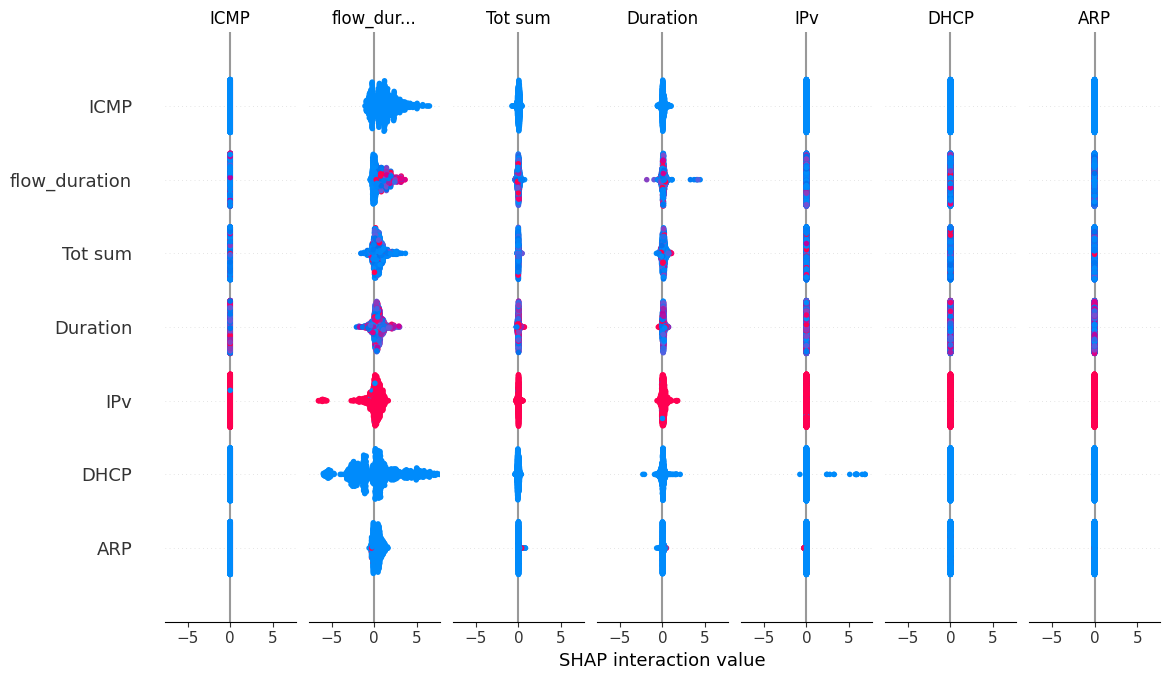

In [11]:
shap.summary_plot(shap_values, X_sample)

## 2. Class-wise SHAP

In [12]:
def plot_class_shap(class_name):
    class_idx = list(le.classes_).index(class_name)

    if isinstance(shap_values, list):
        # old format (list of arrays)
        shap.summary_plot(shap_values[class_idx], X_sample)
    else:
        # new format (3D array)
        shap.summary_plot(shap_values[:, :, class_idx], X_sample)

### Strong class (Example: DDoS)

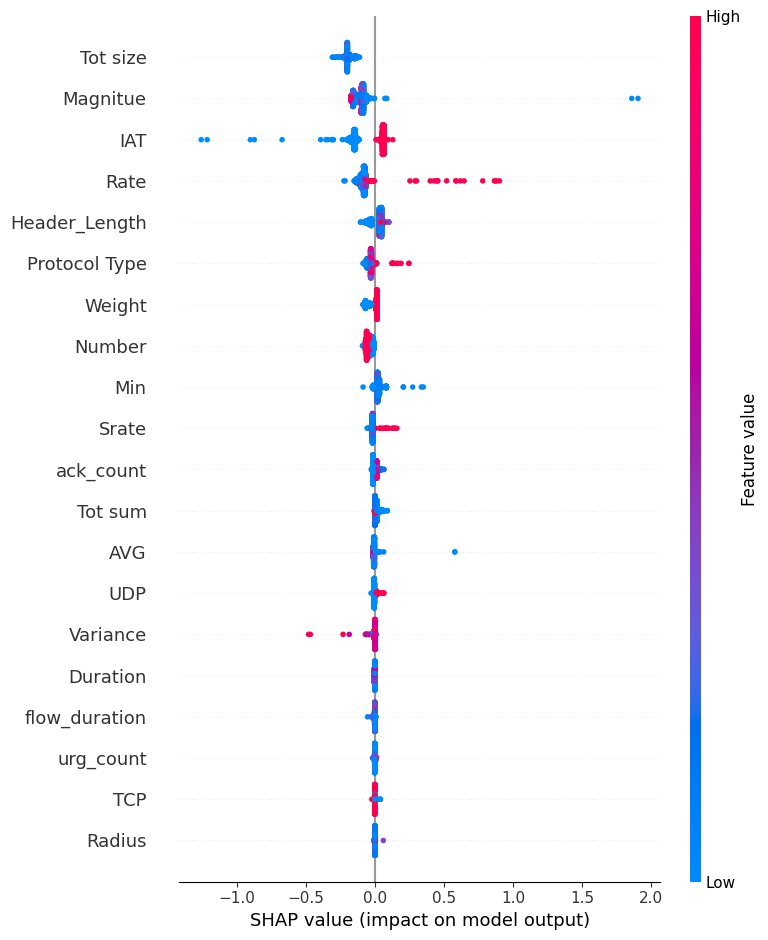

In [13]:
plot_class_shap("DDoS-UDP_Flood")

### Weak class (Example: XSS)

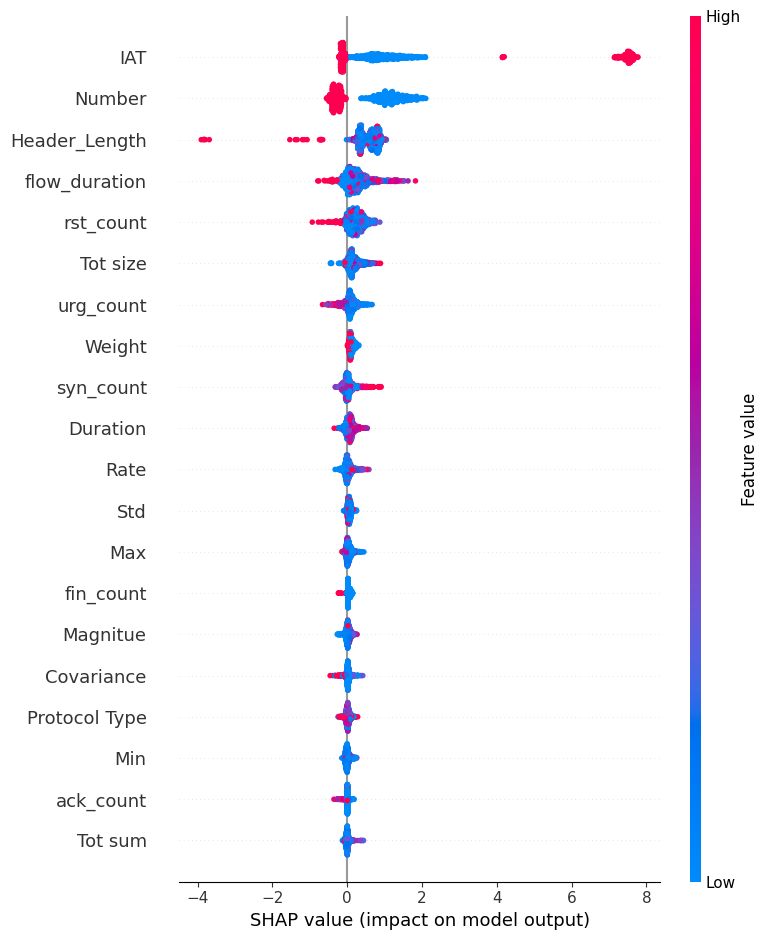

In [14]:
plot_class_shap("XSS")

### Another weak class (Example: Uploading attack)

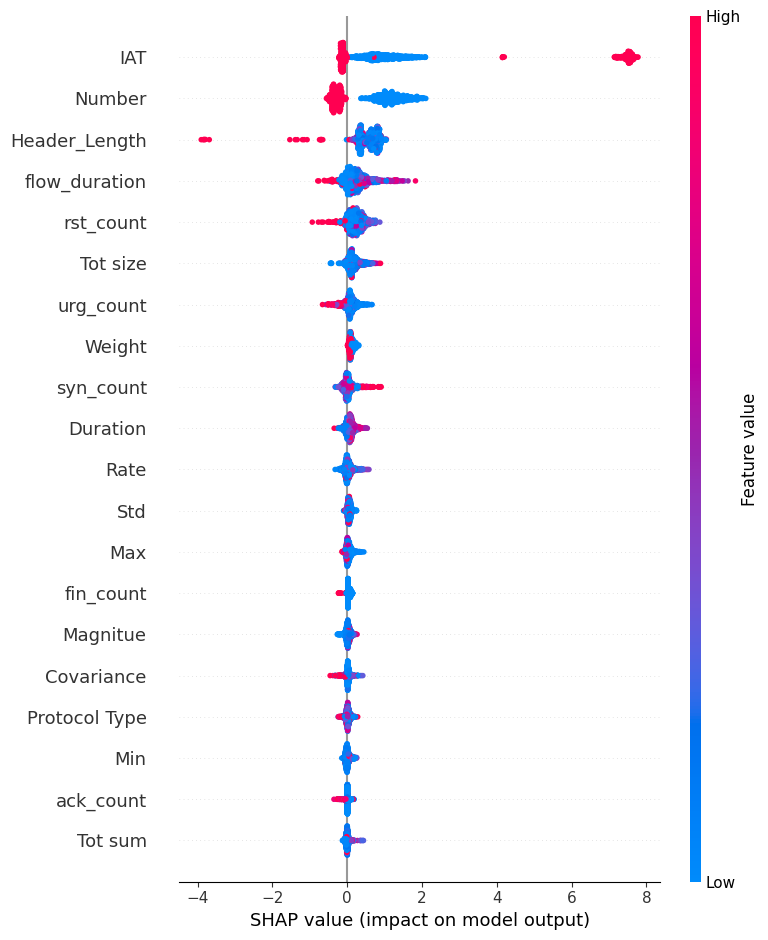

In [15]:
plot_class_shap("XSS")

## 3. Feature importance (SHAP based)

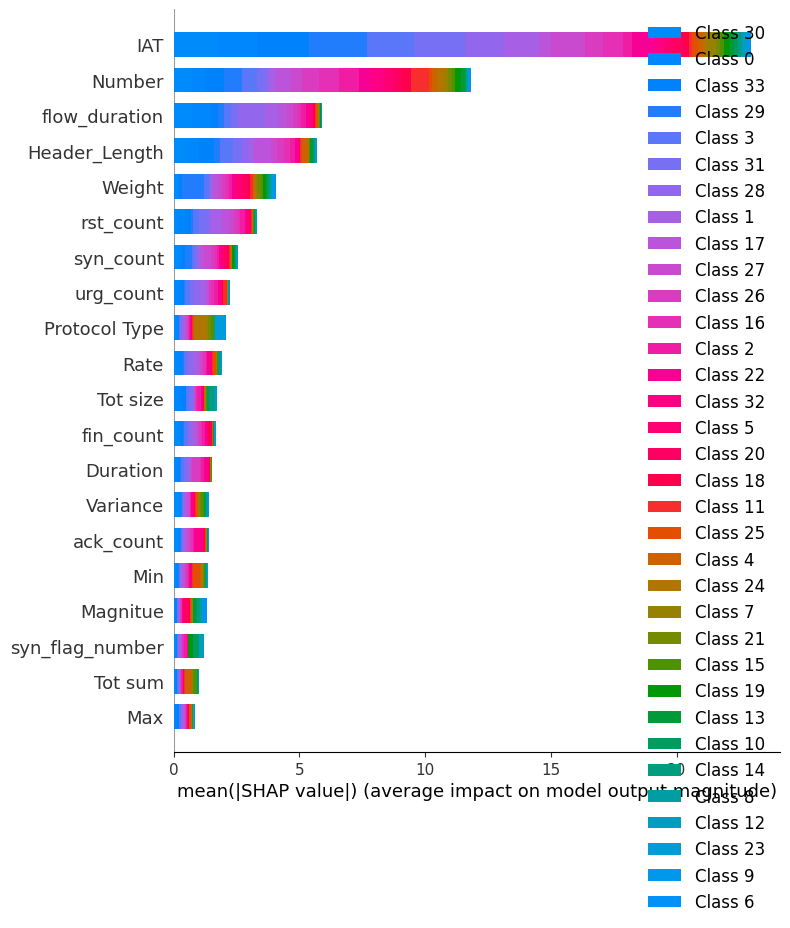

In [16]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

## 4. Individual prediction

### Pick a sample

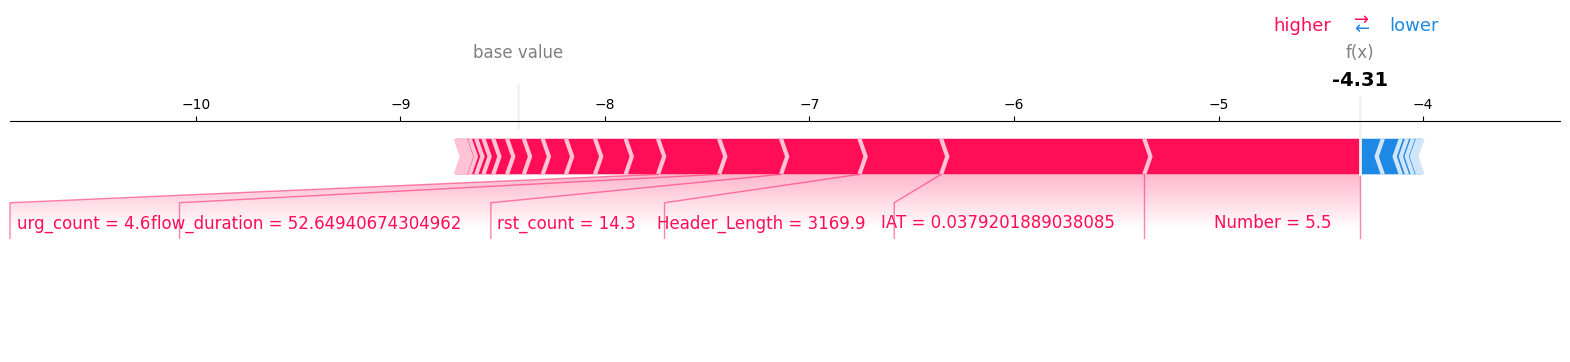

In [17]:
idx = 0  # sample index
class_idx = 0  # pick class (change later)

if isinstance(shap_values, list):
    sv = shap_values[class_idx][idx]
    base = explainer.expected_value[class_idx]
else:
    sv = shap_values[idx, :, class_idx]
    base = explainer.expected_value[class_idx]

shap.force_plot(
    base,
    sv,
    X_sample.iloc[idx],
    matplotlib=True
)

### Waterfall plot

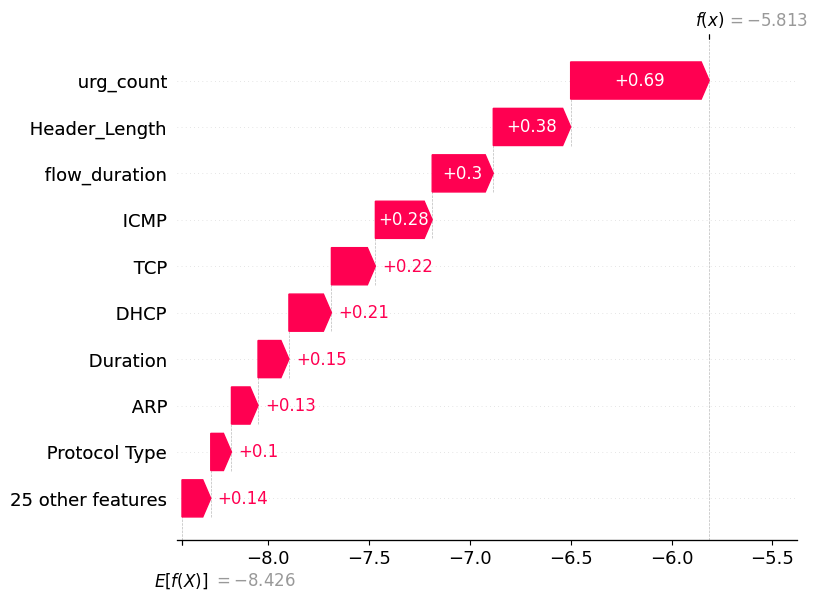

In [18]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0],
    shap_values[0][idx],
    X_sample.iloc[idx]
)

## 5. Correct vs Wrong Prediction

In [19]:
y_sample = y_test[X_sample.index]

In [20]:
y_pred = np.argmax(model.predict(X_sample), axis=1)

correct_indices = np.where(y_pred == y_sample)[0]
wrong_indices   = np.where(y_pred != y_sample)[0]

correct_idx = correct_indices[0] if len(correct_indices) > 0 else None
wrong_idx   = wrong_indices[0] if len(wrong_indices) > 0 else None

print("Correct index:", correct_idx)
print("Wrong index:", wrong_idx)

Correct index: 1
Wrong index: 0


In [21]:
print("Total samples:", len(X_sample))
print("Correct predictions:", len(correct_indices))
print("Wrong predictions:", len(wrong_indices))

Total samples: 1000
Correct predictions: 314
Wrong predictions: 686


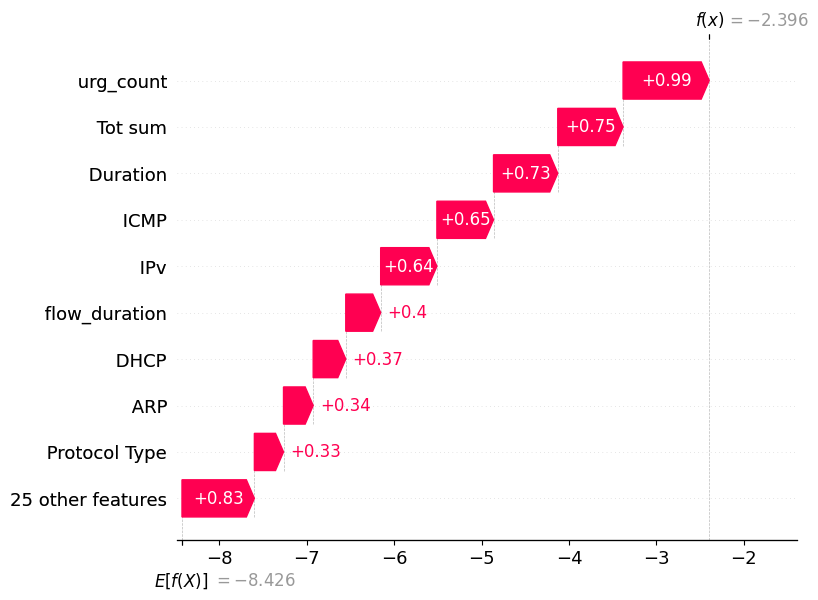

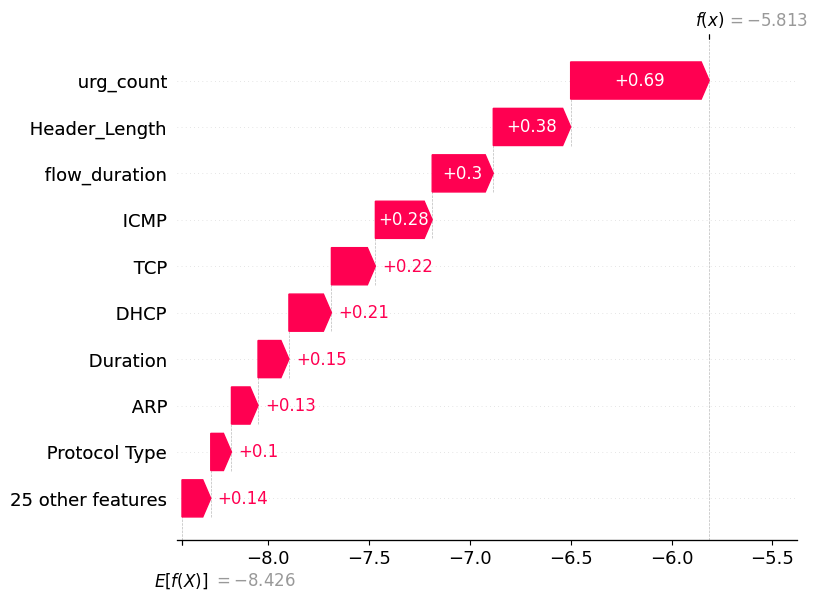

In [22]:
# Correct prediction
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0],
    shap_values[0][correct_idx],
    X_sample.iloc[correct_idx]
)

# Wrong prediction
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0],
    shap_values[0][wrong_idx],
    X_sample.iloc[wrong_idx]
)

In [23]:
print("Key Observations:")

print("\n1. Strong classes (e.g., DDoS) show clear and dominant feature contributions.")
print("2. Weak classes (e.g., XSS, Uploading) show scattered and overlapping feature signals.")
print("3. Misclassifications occur when feature contributions are weak or conflicting.")
print("4. Model relies heavily on a subset of dominant features.")

Key Observations:

1. Strong classes (e.g., DDoS) show clear and dominant feature contributions.
2. Weak classes (e.g., XSS, Uploading) show scattered and overlapping feature signals.
3. Misclassifications occur when feature contributions are weak or conflicting.
4. Model relies heavily on a subset of dominant features.
